---
## Bagian G — Diterapkan pada proyek tim (dikerjakan di luar kelas)

Bagian ini adalah isi **M1**. Kerjakan bersama tim pada dataset proyek Anda sendiri.

### G1 — Pertanyaan analisis

**Pertanyaan payung:** Daerah seperti apa di Indonesia yang paling banyak terkena COVID-19 pada tahun 2022 (1 Januari sampai 15 September)?

| # | Pertanyaan | Kolom yang dipakai | Bentuk jawaban | Tindak lanjut (keputusan, oleh siapa) |
|---|-----------|--------------------|----------------|----------------------------------------|
| 1 | Provinsi mana yang paling banyak dan paling sedikit terkena COVID-19? | `Location`, `New Cases`, `Population`, `Date` | Peringkat (5 teratas dan 5 terbawah) | Provinsi mana yang dicek lebih dulu kesiapan tes dan rumah sakitnya. Oleh Kemenkes dan Dinas Kesehatan provinsi |
| 2 | Apakah provinsi yang lebih padat penduduknya juga lebih banyak terkena? | `Population Density`, `New Cases`, `Population` | Perbandingan 3 kelompok (jarang, sedang, padat) dan sebaran titik tiap provinsi | Apakah kepadatan penduduk dijadikan salah satu pertimbangan awal memilih provinsi prioritas. Oleh Kemenkes dan pemerintah provinsi |
| 3 | Pulau mana yang paling banyak terkena COVID-19? | `Island`, `New Cases`, `Population` | Perbandingan 7 pulau | Apakah persiapan dan pembagian logistik dibedakan per pulau. Oleh Kemenkes dan Dinas Kesehatan provinsi |
| 4 | Dari setiap 1.000 orang yang tercatat terkena, berapa yang meninggal, dan apakah berbeda antarpulau? | `Island`, `New Cases`, `New Deaths` | Perbandingan 7 pulau | Pulau mana yang layanan rujukan dan perawatan intensifnya perlu diperkuat. Oleh Kemenkes dan Dinas Kesehatan provinsi |

**Arti istilah yang dipakai**
- **Terkena** = kasus COVID-19 yang tercatat di data (kolom `New Cases`).
- **Per 1 juta penduduk** = jumlah kasus dibagi jumlah penduduk, lalu dikali 1.000.000. Tujuannya supaya provinsi besar dan provinsi kecil bisa dibandingkan secara adil.
- **Kelompok kepadatan** = 34 provinsi diurutkan dari yang paling jarang sampai paling padat penduduknya, lalu dibagi 3 kelompok hampir sama besar: Jarang (12 provinsi), Sedang (11), Padat (11).
- **Nilai tengah (median)** = nilai yang berada di tengah kalau semua provinsi diurutkan. Dipakai karena DKI Jakarta angkanya sangat ekstrem, sehingga rata-rata biasa bisa menyesatkan.
- **Kematian per 1.000 kasus** = jumlah kematian dibagi jumlah kasus tercatat, dikali 1.000.

**Pertanyaan yang dicoret:** "Apakah vaksinasi menurunkan angka kematian antarprovinsi?" Dicoret karena tidak ada kolom vaksinasi di dataset, diganti pertanyaan 4.

**Catatan:** hasil hanya menunjukkan pola, bukan sebab-akibat. Jumlah kasus yang tercatat juga dipengaruhi banyaknya orang yang dites di tiap daerah.

### G2 — Provenans data
Catat lima butir berikut di README repositori tim:

| Butir | Isi |
|-------|-----|
| Nama sumber | Hendratno (kompilator, Kaggle). Data asli dari covid19.go.id, kemendagri.go.id, bps.go.id, dan bnpb-inacovid19.hub.arcgis.com |
| Tautan atau nama instansi | https://www.kaggle.com/datasets/hendratno/covid19-indonesia |
| Tanggal pengambilan | [28 September 2026]. Isi data mencakup 1 Maret 2020 sampai 16 September 2022 |
| Lisensi atau nomor surat izin | CC BY-NC-SA 4.0 (tertulis di Data Card Kaggle) |
| Kalimat sitasi untuk laporan | Hendratno. *COVID-19 Indonesia Dataset*. Kaggle. https://www.kaggle.com/datasets/hendratno/covid19-indonesia. Diakses [28 September 2026]. Data dikompilasi dari covid19.go.id, kemendagri.go.id, bps.go.id, dan bnpb-inacovid19.hub.arcgis.com. Lisensi CC BY-NC-SA 4.0. |

### G3 — Kamus data
Isi `TEMPLATE_Kamus_Data.csv` untuk **setiap** kolom dataset tim, termasuk kolom `kategori_data_pribadi` dan `tindakan_penanganan`. Simpan sebagai `data_dictionary.md` atau `.csv` di repositori.

In [1]:
import os, re, shutil
import pandas as pd

NAMA_FILE = "covid_19_indonesia_time_series_all.csv"
RAW = f"data/raw/{NAMA_FILE}"
KOLOM_WAJIB = ["Date", "Location", "Location Level", "New Cases", "New Deaths",
               "Population", "Population Density", "Island"]

os.makedirs("data/raw", exist_ok=True)

# Unggah langsung dari laptop (dilewati kalau berkas sudah ada di data/raw/)
if not os.path.exists(RAW):
    from google.colab import files
    print("Klik 'Choose Files' lalu pilih", NAMA_FILE, "dari laptop Anda:")
    unggahan = files.upload()
    assert unggahan, "Tidak ada berkas yang dipilih. Jalankan sel ini lagi."
    shutil.move(next(iter(unggahan)), RAW)

df = pd.read_csv(RAW)

# Validasi: pastikan berkas lengkap, bukan versi yang sudah dipotong
hilang = [c for c in KOLOM_WAJIB if c not in df.columns]
if hilang or len(df) < 20000:
    os.remove(RAW)
    raise ValueError(f"Berkas salah: {len(df)} baris, {df.shape[1]} kolom, kolom wajib hilang: {hilang}. "
                     "Berkas dihapus; jalankan sel ini lagi dan pilih berkas asli dari Kaggle.")

df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
print("Data mentah:", df.shape[0], "baris,", df.shape[1], "kolom")
print("Rentang tanggal:", df["Date"].min().date(), "sampai", df["Date"].max().date())

# Cek kolom pengenal (dasar untuk kolom kategori_data_pribadi di kamus)
POLA = re.compile(r"\bnama\b|\bname\b|\bnik\b|telepon|phone|e-?mail|surel|alamat|address|\bage\b|usia|gender|jenis kelamin", re.I)
pengenal = [c for c in df.columns if POLA.search(c)]
print("Kolom pengenal terdeteksi:", pengenal if pengenal else "tidak ada")

Klik 'Choose Files' lalu pilih covid_19_indonesia_time_series_all.csv dari laptop Anda:


Saving covid_19_indonesia_time_series_all.csv to covid_19_indonesia_time_series_all.csv
Data mentah: 31822 baris, 38 kolom
Rentang tanggal: 2020-03-01 sampai 2022-09-16
Kolom pengenal terdeteksi: tidak ada


In [2]:
import pandas as pd

AGR = "Bukan data pribadi (agregat wilayah)"
ATR = "Bukan data pribadi (atribut wilayah atau waktu)"

kamus = [
 ("Date", "Tanggal pelaporan, format bulan/hari/tahun, tersimpan sebagai teks", "Interval", ATR, "Ubah ke tipe tanggal, filter tahun 2022"),
 ("Location ISO Code", "Kode ISO wilayah (contoh ID-JK; IDN untuk nasional)", "Nominal", ATR, "Simpan, tidak dipakai"),
 ("Location", "Nama wilayah: provinsi atau Indonesia", "Nominal", ATR, "Buang baris Indonesia (nasional)"),
 ("New Cases", "Kasus baru harian", "Rasio", AGR, "Jumlahkan per provinsi selama 2022, sel harian tidak ditampilkan"),
 ("New Deaths", "Kematian baru harian", "Rasio", AGR, "Jumlahkan per provinsi selama 2022, sel harian tidak ditampilkan"),
 ("New Recovered", "Kesembuhan baru harian", "Rasio", AGR, "Simpan, tidak dipakai"),
 ("New Active Cases", "Perubahan jumlah kasus aktif harian", "Interval", AGR, "Simpan, tidak dipakai"),
 ("Total Cases", "Kasus kumulatif sejak awal pandemi", "Rasio", AGR, "Dipakai hanya untuk cek konsistensi"),
 ("Total Deaths", "Kematian kumulatif", "Rasio", AGR, "Simpan, tidak dipakai"),
 ("Total Recovered", "Kesembuhan kumulatif; 288 baris lebih besar dari Total Cases", "Rasio", AGR, "Catat sebagai anomali, tidak dipakai"),
 ("Total Active Cases", "Kasus aktif kumulatif; 479 baris bernilai negatif", "Interval", AGR, "Catat sebagai anomali, tidak dipakai"),
 ("Location Level", "Tingkat wilayah: Province atau Country", "Nominal", ATR, "Filter ke Province"),
 ("City or Regency", "Kota atau kabupaten; kosong 100%", "Nominal", ATR, "Buang dari data olahan"),
 ("Province", "Nama provinsi; kosong untuk baris nasional", "Nominal", ATR, "Simpan, tidak dipakai (pakai Location)"),
 ("Country", "Selalu Indonesia", "Nominal", ATR, "Buang (konstan)"),
 ("Continent", "Selalu Asia", "Nominal", ATR, "Buang (konstan)"),
 ("Island", "Kelompok pulau (7 kelompok)", "Nominal", ATR, "Simpan, dipakai pertanyaan 3 dan 4"),
 ("Time Zone", "Zona waktu (UTC+07:00, +08:00, +09:00)", "Nominal", ATR, "Simpan, tidak dipakai"),
 ("Special Status", "Status khusus daerah (DKI, Istimewa, Khusus); sekitar 86% baris kosong", "Nominal", ATR, "Simpan, tidak dipakai"),
 ("Total Regencies", "Jumlah kabupaten", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Cities", "Jumlah kota", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Districts", "Jumlah kecamatan", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Urban Villages", "Jumlah kelurahan", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Rural Villages", "Jumlah desa", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Area (km2)", "Luas wilayah dalam km2", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Population", "Jumlah penduduk", "Rasio", ATR, "Simpan, dipakai sebagai penyebut per juta"),
 ("Population Density", "Kepadatan penduduk (jiwa per km2)", "Rasio", ATR, "Simpan, dipakai pertanyaan 2"),
 ("Longitude", "Bujur titik pusat wilayah (bukan lokasi individu)", "Interval", ATR, "Simpan, tidak dipakai"),
 ("Latitude", "Lintang titik pusat wilayah (bukan lokasi individu)", "Interval", ATR, "Simpan, tidak dipakai"),
 ("New Cases per Million", "Kasus baru harian per juta penduduk", "Rasio", AGR, "Tidak dipakai (dihitung ulang sendiri)"),
 ("Total Cases per Million", "Kasus kumulatif per juta penduduk", "Rasio", AGR, "Tidak dipakai (bukan khusus 2022)"),
 ("New Deaths per Million", "Kematian baru harian per juta penduduk", "Rasio", AGR, "Tidak dipakai"),
 ("Total Deaths per Million", "Kematian kumulatif per juta penduduk", "Rasio", AGR, "Tidak dipakai"),
 ("Total Deaths per 100rb", "Kematian kumulatif per 100 ribu penduduk", "Rasio", AGR, "Tidak dipakai"),
 ("Case Fatality Rate", "Total Deaths dibagi Total Cases; tersimpan sebagai teks persen; 43 baris di atas 100%", "Rasio", AGR, "Tidak dipakai"),
 ("Case Recovered Rate", "Total Recovered dibagi Total Cases; tersimpan sebagai teks persen", "Rasio", AGR, "Tidak dipakai"),
 ("Growth Factor of New Cases", "Faktor pertumbuhan kasus baru; definisi persis perlu dikonfirmasi ke sumber", "Rasio", AGR, "Tidak dipakai"),
 ("Growth Factor of New Deaths", "Faktor pertumbuhan kematian baru; definisi persis perlu dikonfirmasi ke sumber", "Rasio", AGR, "Tidak dipakai"),
]

kamus_df = pd.DataFrame(kamus, columns=[
    "nama_kolom", "deskripsi", "skala", "kategori_data_pribadi", "tindakan_penanganan"])
kamus_df.to_csv("data_dictionary.csv", index=False, encoding="utf-8")
print(len(kamus_df), "kolom tercatat")
kamus_df.head(38)

38 kolom tercatat


,nama_kolom,deskripsi,skala,kategori_data_pribadi,tindakan_penanganan
0,Date,"Tanggal pelaporan, format bulan/hari/tahun, te...",Interval,Bukan data pribadi (atribut wilayah atau waktu),"Ubah ke tipe tanggal, filter tahun 2022"
1,Location ISO Code,Kode ISO wilayah (contoh ID-JK; IDN untuk nasi...,Nominal,Bukan data pribadi (atribut wilayah atau waktu),"Simpan, tidak dipakai"
2,Location,Nama wilayah: provinsi atau Indonesia,Nominal,Bukan data pribadi (atribut wilayah atau waktu),Buang baris Indonesia (nasional)
3,New Cases,Kasus baru harian,Rasio,Bukan data pribadi (agregat wilayah),"Jumlahkan per provinsi selama 2022, sel harian..."
4,New Deaths,Kematian baru harian,Rasio,Bukan data pribadi (agregat wilayah),"Jumlahkan per provinsi selama 2022, sel harian..."
5,New Recovered,Kesembuhan baru harian,Rasio,Bukan data pribadi (agregat wilayah),"Simpan, tidak dipakai"
6,New Active Cases,Perubahan jumlah kasus aktif harian,Interval,Bukan data pribadi (agregat wilayah),"Simpan, tidak dipakai"
7,Total Cases,Kasus kumulatif sejak awal pandemi,Rasio,Bukan data pribadi (agregat wilayah),Dipakai hanya untuk cek konsistensi
8,Total Deaths,Kematian kumulatif,Rasio,Bukan data pribadi (agregat wilayah),"Simpan, tidak dipakai"
9,Total Recovered,Kesembuhan kumulatif; 288 baris lebih besar da...,Rasio,Bukan data pribadi (agregat wilayah),"Catat sebagai anomali, tidak dipakai"


In [3]:
# G4 — jalankan penanganan pada data tim dan periksa nilai k
import os, re, shutil
import pandas as pd

NAMA_FILE = "covid_19_indonesia_time_series_all.csv"
RAW = f"data/raw/{NAMA_FILE}"
PROCESSED = "data/processed"
K_MIN = 5   #
KOLOM_WAJIB = ["Date", "Location", "Location Level", "New Cases", "New Deaths",
               "Population", "Population Density", "Island"]

os.makedirs("data/raw", exist_ok=True)
os.makedirs(PROCESSED, exist_ok=True)

# Unggah langsung dari laptop (dilewati kalau berkas sudah ada di data/raw/)
if not os.path.exists(RAW):
    from google.colab import files
    print("Klik 'Choose Files' lalu pilih", NAMA_FILE, "dari laptop Anda:")
    unggahan = files.upload()
    assert unggahan, "Tidak ada berkas yang dipilih. Jalankan sel ini lagi."
    nama_unggahan = next(iter(unggahan))
    shutil.move(nama_unggahan, RAW)
    print("Tersimpan di", RAW)

df = pd.read_csv(RAW)

# Validasi: pastikan ini berkas lengkap, bukan versi yang sudah dipotong
hilang = [c for c in KOLOM_WAJIB if c not in df.columns]
if hilang or len(df) < 20000:
    os.remove(RAW)   # hapus berkas yang salah supaya sel bisa dijalankan ulang
    raise ValueError(
        f"Berkas salah: {len(df)} baris, {df.shape[1]} kolom, kolom wajib hilang: {hilang}. "
        "Berkas asli seharusnya sekitar 31.800 baris, 38 kolom, dan ukurannya sekitar 7 MB. "
        "Berkas yang salah sudah dihapus; jalankan sel ini lagi dan pilih berkas asli dari Kaggle.")

df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
print("Data mentah:", df.shape[0], "baris,", df.shape[1], "kolom")
print("Rentang tanggal:", df["Date"].min().date(), "sampai", df["Date"].max().date())

# Cek 1: adakah kolom pengenal langsung atau tidak langsung?
POLA = re.compile(r"\bnama\b|\bname\b|\bnik\b|telepon|phone|e-?mail|surel|alamat|address|\bage\b|usia|gender|jenis kelamin", re.I)
pengenal = [c for c in df.columns if POLA.search(c)]
print("Kolom pengenal terdeteksi:", pengenal if pengenal else "tidak ada")


Data mentah: 31822 baris, 38 kolom
Rentang tanggal: 2020-03-01 sampai 2022-09-16
Kolom pengenal terdeteksi: tidak ada


In [4]:
# Penanganan: hanya provinsi, hanya 2022, buang baris nasional
prov = df[df["Location Level"] == "Province"]
p22 = prov[prov["Date"].dt.year == 2022].copy()
print("Baris provinsi-hari 2022:", len(p22), "| provinsi:", p22["Location"].nunique())
print("Rentang 2022:", p22["Date"].min().date(), "sampai", p22["Date"].max().date())

# k SEBELUM agregasi: satu baris = satu provinsi pada satu hari
def k_terkecil(seri):
    positif = seri[seri > 0]
    return int(positif.min())

k_before = {
    "k_kasus_harian": k_terkecil(p22["New Cases"]),
    "k_kematian_harian": k_terkecil(p22["New Deaths"]),
    "baris_tepat_1_kasus": int((p22["New Cases"] == 1).sum()),
    "baris_1_sampai_4_kasus": int(p22["New Cases"].between(1, 4).sum()),
    "baris_tepat_1_kematian": int((p22["New Deaths"] == 1).sum()),
    "baris_berkematian": int((p22["New Deaths"] > 0).sum()),
    "baris_1_sampai_4_kematian": int(p22["New Deaths"].between(1, 4).sum()),
}
for k, v in k_before.items():
    print(f"{k}: {v}")

Baris provinsi-hari 2022: 8770 | provinsi: 34
Rentang 2022: 2022-01-01 sampai 2022-09-15
k_kasus_harian: 1
k_kematian_harian: 1
baris_tepat_1_kasus: 802
baris_1_sampai_4_kasus: 2064
baris_tepat_1_kematian: 1032
baris_berkematian: 2599
baris_1_sampai_4_kematian: 1953


In [5]:
# Agregasi: satu baris = satu provinsi untuk seluruh periode 2022
hasil = (p22.groupby("Location")
         .agg(pulau=("Island", "first"),
              penduduk=("Population", "first"),
              kepadatan=("Population Density", "first"),
              hari_data=("Date", "nunique"),
              kasus=("New Cases", "sum"),
              kematian=("New Deaths", "sum"))
         .reset_index()
         .rename(columns={"Location": "provinsi"}))
hasil["kasus_per_juta"] = hasil["kasus"] / hasil["penduduk"] * 1_000_000
hasil["kematian_per_juta"] = hasil["kematian"] / hasil["penduduk"] * 1_000_000

# k SESUDAH agregasi
i_kasus = hasil["kasus"].idxmin()
i_mati = hasil["kematian"].idxmin()
k_after = {
    "k_kasus_provinsi": int(hasil.loc[i_kasus, "kasus"]),
    "provinsi_k_kasus": hasil.loc[i_kasus, "provinsi"],
    "k_kematian_provinsi": int(hasil.loc[i_mati, "kematian"]),
    "provinsi_k_kematian": hasil.loc[i_mati, "provinsi"],
}
print(k_after)
lulus = min(k_after["k_kasus_provinsi"], k_after["k_kematian_provinsi"]) >= K_MIN
print(f"Ambang k >= {K_MIN}:", "LULUS" if lulus else "GAGAL: gabungkan atau sembunyikan sel yang di bawah ambang")

hasil.sort_values("kasus_per_juta", ascending=False).head(5)

{'k_kasus_provinsi': 2102, 'provinsi_k_kasus': 'Gorontalo', 'k_kematian_provinsi': 20, 'provinsi_k_kematian': 'Papua'}
Ambang k >= 5: LULUS


,provinsi,pulau,penduduk,kepadatan,hari_data,kasus,kematian,kasus_per_juta,kematian_per_juta
4,DKI Jakarta,Jawa,10846145,16334.31,258,547214,1904,50452.395759,175.546242
2,Banten,Jawa,10722374,1109.64,258,201049,256,18750.418517,23.875310
5,Daerah Istimewa Yogyakarta,Jawa,3631015,1158.90,258,67310,659,18537.516369,181.491952
15,Kalimantan Utara,Kalimantan,648407,8.59,258,9477,49,14615.820002,75.569820
14,Kalimantan Timur,Kalimantan,3552191,27.52,258,50685,274,14268.658414,77.135492


In [6]:
# Simpan hasil olahan dan catatan k ke data/processed/ (BUKAN ke data/raw/)
hasil.to_csv(f"{PROCESSED}/covid_2022_provinsi.csv", index=False, encoding="utf-8")

catatan_k = pd.DataFrame(
    [("sebelum agregasi (provinsi-hari)", k, v) for k, v in k_before.items()] +
    [("sesudah agregasi (provinsi, 2022)", k, v) for k, v in k_after.items()] +
    [("ambang", "K_MIN", K_MIN)],
    columns=["tahap", "ukuran", "nilai"])
catatan_k.to_csv(f"{PROCESSED}/catatan_k.csv", index=False, encoding="utf-8")

print("Tersimpan di", PROCESSED, ":", sorted(os.listdir(PROCESSED)))
catatan_k

Tersimpan di data/processed : ['catatan_k.csv', 'covid_2022_provinsi.csv']


,tahap,ukuran,nilai
0,sebelum agregasi (provinsi-hari),k_kasus_harian,1
1,sebelum agregasi (provinsi-hari),k_kematian_harian,1
2,sebelum agregasi (provinsi-hari),baris_tepat_1_kasus,802
3,sebelum agregasi (provinsi-hari),baris_1_sampai_4_kasus,2064
4,sebelum agregasi (provinsi-hari),baris_tepat_1_kematian,1032
5,sebelum agregasi (provinsi-hari),baris_berkematian,2599
6,sebelum agregasi (provinsi-hari),baris_1_sampai_4_kematian,1953
7,"sesudah agregasi (provinsi, 2022)",k_kasus_provinsi,2102
8,"sesudah agregasi (provinsi, 2022)",provinsi_k_kasus,Gorontalo
9,"sesudah agregasi (provinsi, 2022)",k_kematian_provinsi,20


## Hasil dan jawaban (Q1–Q4)

Semua angka di bagian ini berupa total per provinsi atau per pulau untuk seluruh periode 1 Januari sampai 15 September 2022. Tidak ada angka harian per provinsi yang ditampilkan.

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

os.makedirs("hasil/grafik", exist_ok=True)
os.makedirs("hasil/tabel", exist_ok=True)

# format angka gaya Indonesia: titik untuk ribuan, koma untuk desimal
ribuan = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))

def rb(x, d=0):
    return f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")

## Visualisasi (Q1–Q4)

In [8]:
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

os.makedirs("hasil/grafik", exist_ok=True)
os.makedirs("hasil/tabel", exist_ok=True)

### Q1 — Provinsi mana yang paling banyak dan paling sedikit terkena COVID-19?

**Cara membaca:** semakin panjang batang, semakin besar bagian penduduk provinsi itu yang tercatat terkena COVID-19. Merah = 5 provinsi terbanyak, biru = 5 provinsi tersedikit.

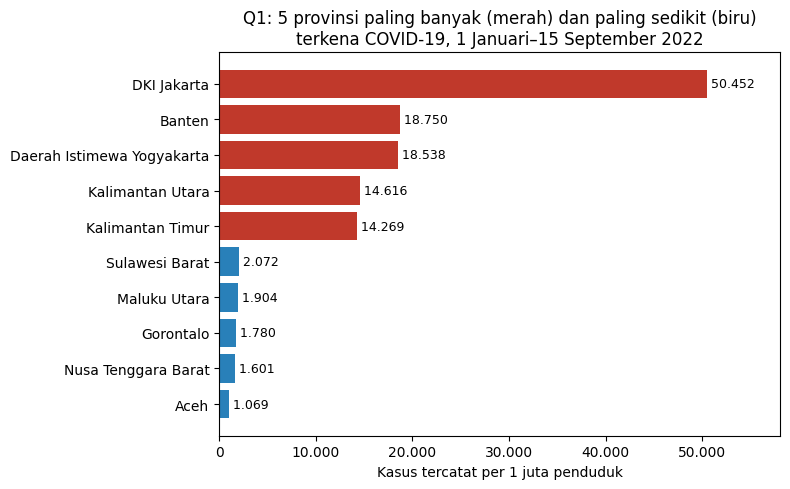

Terbanyak: DKI Jakarta (50.452 per 1 juta, sekitar 1 dari 20 penduduk)
Tersedikit: Aceh (1.069 per 1 juta, sekitar 1 dari 936 penduduk)
Selisihnya sekitar 47 kali lipat


In [9]:
urut = hasil.sort_values("kasus_per_juta", ascending=False)
atas, bawah = urut.head(5), urut.tail(5)
q1 = pd.concat([atas, bawah]).sort_values("kasus_per_juta")

fig, ax = plt.subplots(figsize=(8, 5))
warna = ["#c0392b" if p in atas["provinsi"].values else "#2980b9" for p in q1["provinsi"]]
batang = ax.barh(q1["provinsi"], q1["kasus_per_juta"], color=warna)
for b, nilai in zip(batang, q1["kasus_per_juta"]):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + rb(nilai), va="center", fontsize=9)
ax.set_xlim(0, q1["kasus_per_juta"].max() * 1.15)
ax.xaxis.set_major_formatter(ribuan)
ax.set_xlabel("Kasus tercatat per 1 juta penduduk")
ax.set_title("Q1: 5 provinsi paling banyak (merah) dan paling sedikit (biru)\nterkena COVID-19, 1 Januari–15 September 2022")
plt.tight_layout()
plt.savefig("hasil/grafik/q1_top5_bottom5.png", dpi=150)
plt.show()

q1[["provinsi", "pulau", "kasus", "penduduk", "kasus_per_juta"]].round(1).to_csv(
    "hasil/tabel/q1_top5_bottom5.csv", index=False, encoding="utf-8")

tertinggi, terendah = urut.iloc[0], urut.iloc[-1]
print(f"Terbanyak: {tertinggi['provinsi']} ({rb(tertinggi['kasus_per_juta'])} per 1 juta, sekitar 1 dari {tertinggi['penduduk']/tertinggi['kasus']:.0f} penduduk)")
print(f"Tersedikit: {terendah['provinsi']} ({rb(terendah['kasus_per_juta'])} per 1 juta, sekitar 1 dari {terendah['penduduk']/terendah['kasus']:.0f} penduduk)")
print(f"Selisihnya sekitar {tertinggi['kasus_per_juta']/terendah['kasus_per_juta']:.0f} kali lipat")

### Q2 — Apakah provinsi yang lebih padat penduduknya juga lebih banyak terkena?

**Cara membaca:** 34 provinsi dibagi 3 kelompok berdasarkan kepadatan penduduk. Satu titik = satu provinsi, makin tinggi titiknya makin banyak penduduknya yang terkena. Garis putus-putus adalah nilai tengah tiap kelompok, jadi bisa dibandingkan langsung antar kelompok.

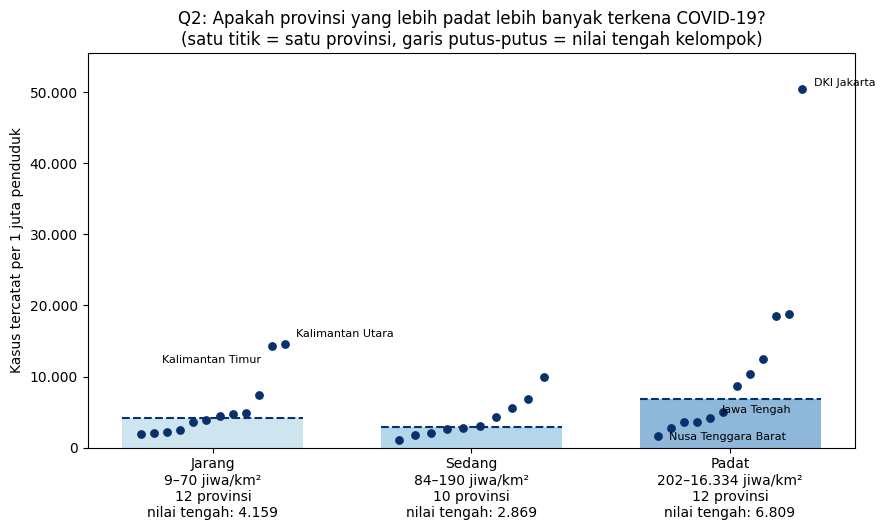

,jumlah_provinsi,kepadatan_terendah,kepadatan_tertinggi,nilai_tengah_kasus_per_juta
kelompok_kepadatan,,,,
Jarang,12,8.6,69.8,4158.8
Sedang,10,84.0,190.2,2868.8
Padat,12,201.8,16334.3,6809.0


In [10]:
hasil["kelompok_kepadatan"] = pd.qcut(hasil["kepadatan"], 3, labels=["Jarang", "Sedang", "Padat"])
q2 = (hasil.groupby("kelompok_kepadatan", observed=True)
      .agg(jumlah_provinsi=("provinsi", "count"),
           kepadatan_terendah=("kepadatan", "min"),
           kepadatan_tertinggi=("kepadatan", "max"),
           nilai_tengah_kasus_per_juta=("kasus_per_juta", "median")))

fig, ax = plt.subplots(figsize=(9, 5.4))
warna_k = {"Jarang": "#9ecae1", "Sedang": "#6baed6", "Padat": "#2171b5"}
sorot = {"DKI Jakarta": (8, 2, "left"), "Kalimantan Utara": (8, 5, "left"),
         "Kalimantan Timur": (-8, -12, "right"), "Jawa Tengah": (8, 4, "left"),
         "Nusa Tenggara Barat": (8, -3, "left")}
xt, xl = [], []
for i, (k, baris) in enumerate(q2.iterrows()):
    med = baris["nilai_tengah_kasus_per_juta"]
    ax.bar(i, med, width=0.7, color=warna_k[k], alpha=0.5, zorder=1)
    ax.hlines(med, i - 0.35, i + 0.35, colors="#08306b", linestyles="--", linewidth=1.5, zorder=2)
    d = hasil[hasil["kelompok_kepadatan"] == k].sort_values("kasus_per_juta")
    geser = np.linspace(-0.28, 0.28, len(d))
    ax.scatter(i + geser, d["kasus_per_juta"], s=28, color="#08306b", zorder=3)
    for g, (_, r) in zip(geser, d.iterrows()):
        if r["provinsi"] in sorot:
            dx, dy, ha = sorot[r["provinsi"]]
            ax.annotate(r["provinsi"], (i + g, r["kasus_per_juta"]), xytext=(dx, dy),
                        textcoords="offset points", fontsize=8, ha=ha, zorder=5)
    xt.append(i)
    xl.append(f"{k}\n{rb(baris['kepadatan_terendah'])}–{rb(baris['kepadatan_tertinggi'])} jiwa/km²\n"
              f"{int(baris['jumlah_provinsi'])} provinsi\nnilai tengah: {rb(med)}")
ax.set_xticks(xt)
ax.set_xticklabels(xl)
ax.yaxis.set_major_formatter(ribuan)
ax.set_ylim(0, hasil["kasus_per_juta"].max() * 1.1)
ax.set_ylabel("Kasus tercatat per 1 juta penduduk")
ax.set_title("Q2: Apakah provinsi yang lebih padat lebih banyak terkena COVID-19?\n(satu titik = satu provinsi, garis putus-putus = nilai tengah kelompok)")
plt.tight_layout()
plt.savefig("hasil/grafik/q2_kelompok_kepadatan.png", dpi=150)
plt.show()

q2.round(1).to_csv("hasil/tabel/q2_kelompok_kepadatan.csv", encoding="utf-8")
q2.round(1)

### Q3 — Pulau mana yang paling banyak terkena COVID-19?

**Cara membaca:** angka di ujung batang adalah jumlah kasus tercatat untuk setiap 1 juta penduduk di pulau itu. Dihitung dari total kasus dan total penduduk seluruh provinsi di pulau tersebut. Angka dalam kurung adalah jumlah provinsinya.

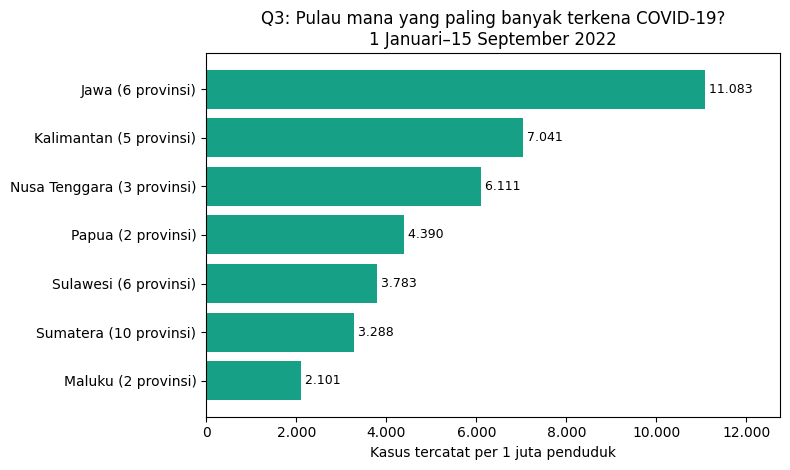

Jawa tanpa DKI Jakarta: 7.951 per 1 juta


,jumlah_provinsi,kasus,penduduk,kasus_per_juta
pulau,,,,
Jawa,6,1631428,147203954,11082.8
Kalimantan,5,114175,16216750,7040.6
Nusa Tenggara,3,91044,14897739,6111.3
Papua,2,24063,5481049,4390.2
Sulawesi,6,77166,20400432,3782.6
Sumatera,10,190154,57830696,3288.1
Maluku,2,6630,3154900,2101.5


In [11]:
pulau = (hasil.groupby("pulau")
         .agg(jumlah_provinsi=("provinsi", "count"), penduduk=("penduduk", "sum"),
              kasus=("kasus", "sum"), kematian=("kematian", "sum")))
pulau["kasus_per_juta"] = pulau["kasus"] / pulau["penduduk"] * 1_000_000
pulau["kematian_per_juta"] = pulau["kematian"] / pulau["penduduk"] * 1_000_000
pulau["kematian_per_1000_kasus"] = pulau["kematian"] / pulau["kasus"] * 1000

q3 = pulau.sort_values("kasus_per_juta", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.8))
label = [f"{p} ({int(n)} provinsi)" for p, n in zip(q3.index, q3["jumlah_provinsi"])]
batang = ax.barh(label, q3["kasus_per_juta"], color="#16a085")
for b, v in zip(batang, q3["kasus_per_juta"]):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + rb(v), va="center", fontsize=9)
ax.set_xlim(0, q3["kasus_per_juta"].max() * 1.15)
ax.xaxis.set_major_formatter(ribuan)
ax.set_xlabel("Kasus tercatat per 1 juta penduduk")
ax.set_title("Q3: Pulau mana yang paling banyak terkena COVID-19?\n1 Januari–15 September 2022")
plt.tight_layout()
plt.savefig("hasil/grafik/q3_bar_pulau_kasus.png", dpi=150)
plt.show()

pulau.sort_values("kasus_per_juta", ascending=False).round(1).to_csv(
    "hasil/tabel/q3_pulau_kasus.csv", encoding="utf-8")

# pemeriksaan: apakah Jawa masih tertinggi kalau DKI Jakarta dikeluarkan?
jawa = hasil[(hasil["pulau"] == "Jawa") & (hasil["provinsi"] != "DKI Jakarta")]
print(f"Jawa tanpa DKI Jakarta: {rb(jawa['kasus'].sum() / jawa['penduduk'].sum() * 1_000_000)} per 1 juta")
pulau.sort_values("kasus_per_juta", ascending=False)[["jumlah_provinsi", "kasus", "penduduk", "kasus_per_juta"]].round(1)

### Q4 — Dari setiap 1.000 orang yang tercatat terkena, berapa yang meninggal?

**Cara membaca:** semakin panjang batang, semakin banyak yang meninggal dari setiap 1.000 kasus tercatat. Garis putus-putus adalah rata-rata seluruh Indonesia. Pulau di sebelah kanan garis lebih tinggi dari rata-rata nasional.

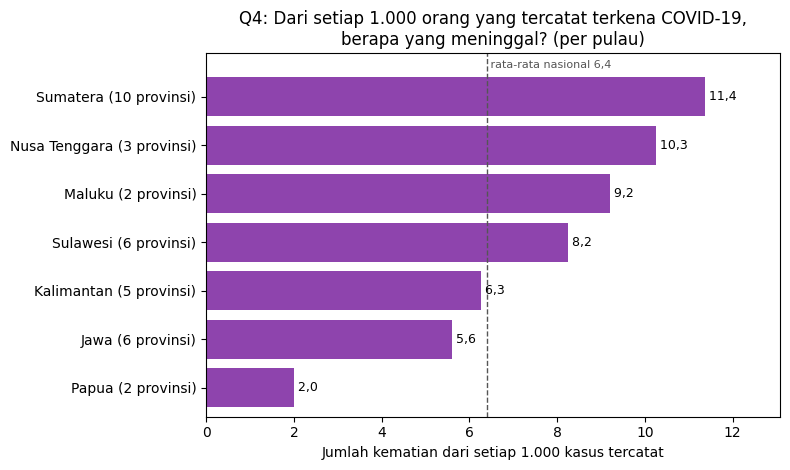

,jumlah_provinsi,kasus,kematian,kematian_per_1000_kasus,kematian_per_juta
pulau,,,,,
Sumatera,10,190154,2163,11.4,37.4
Nusa Tenggara,3,91044,934,10.3,62.7
Maluku,2,6630,61,9.2,19.3
Sulawesi,6,77166,636,8.2,31.2
Kalimantan,5,114175,716,6.3,44.2
Jawa,6,1631428,9125,5.6,62.0
Papua,2,24063,48,2.0,8.8


In [12]:
nasional = hasil["kematian"].sum() / hasil["kasus"].sum() * 1000
q4 = pulau.sort_values("kematian_per_1000_kasus", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))
label = [f"{p} ({int(n)} provinsi)" for p, n in zip(q4.index, q4["jumlah_provinsi"])]
batang = ax.barh(label, q4["kematian_per_1000_kasus"], color="#8e44ad")
for b, v in zip(batang, q4["kematian_per_1000_kasus"]):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + rb(v, 1), va="center", fontsize=9)
ax.axvline(nasional, color="#555555", linestyle="--", linewidth=1)
ax.text(nasional, len(q4) - 0.45, f" rata-rata nasional {rb(nasional, 1)}", fontsize=8, color="#555555", va="bottom")
ax.set_xlim(0, q4["kematian_per_1000_kasus"].max() * 1.15)
ax.set_ylim(-0.6, len(q4) - 0.1)
ax.set_xlabel("Jumlah kematian dari setiap 1.000 kasus tercatat")
ax.set_title("Q4: Dari setiap 1.000 orang yang tercatat terkena COVID-19,\nberapa yang meninggal? (per pulau)")
plt.tight_layout()
plt.savefig("hasil/grafik/q4_bar_pulau_kematian.png", dpi=150)
plt.show()

pulau.sort_values("kematian_per_1000_kasus", ascending=False).round(1).to_csv(
    "hasil/tabel/q4_pulau_kematian.csv", encoding="utf-8")
pulau.sort_values("kematian_per_1000_kasus", ascending=False)[
    ["jumlah_provinsi", "kasus", "kematian", "kematian_per_1000_kasus", "kematian_per_juta"]].round(1)

### Simpan hasil olahan untuk pertanyaan Q1–Q4

Sel ini memperbarui isi `data/processed/` agar sesuai dengan pertanyaan terbaru: kolom kelompok kepadatan (Q2) dan kematian per 1.000 kasus (Q4) ditambahkan ke tabel provinsi, tabel per pulau (Q3 dan Q4) disimpan, dan nilai k untuk tabel yang ditampilkan dicatat.

In [13]:
hasil["kematian_per_1000_kasus"] = hasil["kematian"] / hasil["kasus"] * 1000
hasil.round(2).to_csv(f"{PROCESSED}/covid_2022_provinsi.csv", index=False, encoding="utf-8")
pulau.round(2).to_csv(f"{PROCESSED}/covid_2022_pulau.csv", encoding="utf-8")

# nilai k untuk tabel yang benar-benar ditampilkan (per pulau dan per kelompok kepadatan)
kel = hasil.groupby("kelompok_kepadatan", observed=True)[["kasus", "kematian"]].sum()
k_tampil = pd.DataFrame([
    ("tabel yang ditampilkan", "k_kasus_terkecil_per_pulau", int(pulau["kasus"].min())),
    ("tabel yang ditampilkan", "pulau_k_kasus", pulau["kasus"].idxmin()),
    ("tabel yang ditampilkan", "k_kematian_terkecil_per_pulau", int(pulau["kematian"].min())),
    ("tabel yang ditampilkan", "pulau_k_kematian", pulau["kematian"].idxmin()),
    ("tabel yang ditampilkan", "k_kasus_terkecil_per_kelompok_kepadatan", int(kel["kasus"].min())),
    ("tabel yang ditampilkan", "k_kematian_terkecil_per_kelompok_kepadatan", int(kel["kematian"].min())),
], columns=["tahap", "ukuran", "nilai"])
catatan_k_lengkap = pd.concat([catatan_k, k_tampil], ignore_index=True)
catatan_k_lengkap.to_csv(f"{PROCESSED}/catatan_k.csv", index=False, encoding="utf-8")

print("Tersimpan di", PROCESSED, ":", sorted(os.listdir(PROCESSED)))
k_tampil

Tersimpan di data/processed : ['catatan_k.csv', 'covid_2022_provinsi.csv', 'covid_2022_pulau.csv']


,tahap,ukuran,nilai
0,tabel yang ditampilkan,k_kasus_terkecil_per_pulau,6630
1,tabel yang ditampilkan,pulau_k_kasus,Maluku
2,tabel yang ditampilkan,k_kematian_terkecil_per_pulau,48
3,tabel yang ditampilkan,pulau_k_kematian,Papua
4,tabel yang ditampilkan,k_kasus_terkecil_per_kelompok_kepadatan,133430
5,tabel yang ditampilkan,k_kematian_terkecil_per_kelompok_kepadatan,1243


### Kesimpulan

**Jawaban pertanyaan payung:** daerah yang paling banyak terkena COVID-19 pada 2022 adalah daerah yang padat penduduknya dan berada di Pulau Jawa, terutama DKI Jakarta. Namun polanya tidak rapi, ada beberapa pengecualian yang penting.

1. **Q1.** DKI Jakarta paling banyak terkena (sekitar 50.452 kasus per 1 juta penduduk, kira-kira 1 dari 20 penduduk). Aceh paling sedikit (sekitar 1.069 per 1 juta). Selisihnya sekitar 47 kali lipat.
2. **Q2.** Kelompok provinsi paling padat punya nilai tengah paling tinggi (8.641 per 1 juta), kira-kira dua kali kelompok paling jarang (4.159). Tetapi kelompok sedang justru paling rendah (3.035), dan ada pengecualian: Kalimantan Utara dan Kalimantan Timur sangat jarang penduduknya namun termasuk 5 provinsi tertinggi, sedangkan Jawa Tengah dan Nusa Tenggara Barat padat tetapi angkanya rendah. Jadi kepadatan membantu menjelaskan, tetapi bukan satu-satunya faktor.
3. **Q3.** Jawa paling tinggi (sekitar 11.083 per 1 juta), disusul Kalimantan (7.041). Kalau DKI Jakarta dikeluarkan, Jawa turun menjadi sekitar 7.951 dan hanya sedikit di atas Kalimantan, jadi keunggulan Jawa sebagian besar berasal dari Jakarta.
4. **Q4.** Pulau dengan kasus terbanyak bukan yang paling mematikan per kasus. Sumatera paling tinggi (sekitar 11,4 kematian per 1.000 kasus), Jawa lebih rendah (5,6), dan rata-rata nasional 6,4. Papua paling rendah (2,0).

**Hal yang perlu diingat:**
- Hasil ini menunjukkan pola, bukan sebab-akibat.
- Kasus yang tercatat dipengaruhi banyaknya tes. Provinsi yang lebih banyak mengetes akan tampak punya kasus lebih banyak, dan angka kematian per 1.000 kasus bisa tampak lebih tinggi di tempat yang jarang mengetes.
- Pulau Maluku dan Papua masing-masing hanya terdiri dari 2 provinsi, sehingga angkanya mudah berubah oleh satu provinsi saja.
- Data tidak memuat vaksinasi, usia, atau fasilitas kesehatan, sehingga tidak bisa menjelaskan alasan di balik perbedaannya.

### G5 — Daftar periksa sebelum `git push`

- [ ] `data/raw/` masuk `.gitignore`
- [ ] Tidak ada nama, NIK, nomor telepon, surel, atau alamat di berkas mana pun
- [ ] Keluaran sel yang sempat menampilkan data pribadi sudah dibersihkan
- [ ] Garam hash tidak tertulis di dalam notebook
- [ ] Kamus data memuat kategori dan tindakan untuk setiap kolom
- [ ] Nilai k pada data yang diunggah sudah dihitung dan dicatat
- [ ] Bila masih ragu: repositori dibuat **privat**

> Menghapus berkas lalu *commit* ulang **tidak** menghilangkan data dari riwayat Git. > Periksa **sebelum** *commit* pertama.